# Week 4 — 30-min aggregated vs continuous HMMs

**Question:** on a regularly sampled CO2 series, do covariate-driven *discrete* HMMs (Gaussian and autoregressive) beat the *continuous-time* HMMs at predicting CO2 **3 hours ahead**?

We aggregate the raw CO2 to 30-minute bins, keep the longest gap-free run, and train two discrete covariate HMMs on it. The continuous models train on the *raw* readings inside the same datetime window. We also add a **continuous-time autoregressive** emission whose AR pull on the previous observation decays with the waiting time as $e^{-\lambda\,\Delta t}$ (so a long gap erases the carry-over) — trained on both the raw and 30-min data. All models are compared with a rolling **fixed 3-hour-ahead** forecast on one shared held-out test period (RMSE / MAPE / R²).

In [1]:
import jax
jax.config.update("jax_enable_x64", True)

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import jax.numpy as jnp

from src.api.v4 import (
    HMM, GaussEmission, AutoregressiveGaussEmission,
    DynamicTransition, ContinuousStaticTransition, ContinuousDynamicTransition,
    ForwardAlgorithm,
)
from src.base.utils import transition_matrix_to_logits

## Config

In [2]:
room_name   = "Room 009"
STATES      = 4
AR_LAGS     = 1
TEST_SIZE   = 0.2
BIN         = "30min"
HORIZON_HOURS = 3
SECONDS     = 600      # nominal raw sampling (~600 s); continuous time unit
BIN_SECONDS = 1800     # 30 min

SERIES_PATH = "data/raw/dtu/timeseries"

## Load and clean the raw series

Drop NaN CO2, the 4000+ ppm sensor-saturation ceiling, and exact duplicate `(datetime, co2)` readings.

In [3]:
series_df = pd.read_csv(Path(SERIES_PATH) / f"{room_name}.csv")
series_df = series_df.dropna(subset=["co2"]).copy()
series_df["datetime"] = pd.to_datetime(series_df["datetime"])

non_saturated = series_df[(series_df["co2"] <= 4000) & series_df["co2"].notna()]
df_raw = (
    non_saturated.drop_duplicates(subset=["datetime", "co2"])
    .sort_values("datetime")
    .reset_index(drop=True)[["datetime", "co2"]]
)
print(f"{room_name}: {len(df_raw)} cleaned raw observations")
print(f"  from {df_raw['datetime'].iloc[0]} to {df_raw['datetime'].iloc[-1]}")

Room 009: 14346 cleaned raw observations
  from 2023-11-01 00:01:53 to 2024-02-09 13:05:40


## Covariate builder

`build_covariates(datetimes)` returns an `(N, D)` matrix of an off-day flag, cyclical week / time-of-day encodings, and hourly weather matched by time. Copied verbatim from `week_4.ipynb`.

In [4]:
# --- Holidays -----------------------------------------------------------
try:
    import holidays as _holidays
    _dk_holidays = _holidays.Denmark()

    def _is_holiday(d):
        return d.date() in _dk_holidays
except ImportError:
    _DK_HOLIDAYS = {
        pd.Timestamp("2024-01-01"), pd.Timestamp("2024-03-28"), pd.Timestamp("2024-03-29"),
        pd.Timestamp("2024-03-31"), pd.Timestamp("2024-04-01"), pd.Timestamp("2024-04-26"),
        pd.Timestamp("2024-05-09"), pd.Timestamp("2024-05-19"), pd.Timestamp("2024-05-20"),
        pd.Timestamp("2024-12-25"), pd.Timestamp("2024-12-26"),
    }

    def _is_holiday(d):
        return d.normalize() in _DK_HOLIDAYS

# --- Weather ------------------------------------------------------------
weather_cols = [
    "mean_temp", "mean_relative_hum", "mean_wind_speed",
    "mean_pressure", "mean_cloud_cover", "mean_radiation",
]
weather_df = pd.read_csv("data/raw/dtu/weather.csv", parse_dates=["DateFrom", "DateTo"])
weather_df = (
    weather_df[["DateFrom", *weather_cols]].dropna().sort_values("DateFrom").reset_index(drop=True)
)


def _weather_features(datetimes):
    """Match hourly weather (UTC) to each local, tz-naive observation time."""
    local = pd.DatetimeIndex(datetimes).tz_localize(
        "Europe/Copenhagen", ambiguous="NaT", nonexistent="shift_forward"
    )
    left = pd.DataFrame({"t": local.tz_convert("UTC")})
    left["order"] = np.arange(len(left))
    left = left.sort_values("t")
    merged = pd.merge_asof(
        left, weather_df.rename(columns={"DateFrom": "t"}), on="t", direction="nearest",
    )
    merged = merged.sort_values("order")
    return merged[weather_cols].ffill().bfill().to_numpy()


def build_covariates(datetimes):
    """Return an (N, D) covariate matrix for a series of pandas datetimes."""
    dt = pd.DatetimeIndex(datetimes)
    is_weekend = dt.dayofweek >= 5
    is_holiday = np.array([_is_holiday(d) for d in dt])
    off_day = (is_weekend | is_holiday).astype(float)

    seconds_into_week = dt.dayofweek * 86400 + dt.hour * 3600 + dt.minute * 60 + dt.second
    week_angle = 2 * np.pi * seconds_into_week / (7 * 86400)
    sin_week, cos_week = np.sin(week_angle), np.cos(week_angle)

    seconds_into_day = dt.hour * 3600 + dt.minute * 60 + dt.second
    tod_angle = 2 * np.pi * seconds_into_day / 86400
    sin_tod, cos_tod = np.sin(tod_angle), np.cos(tod_angle)

    calendar = np.column_stack([off_day, sin_week, cos_week, sin_tod, cos_tod])
    weather = _weather_features(datetimes)
    return np.column_stack([calendar, weather])

covariate_cols = ["off_day", "sin_week", "cos_week", "sin_tod", "cos_tod", *weather_cols]

## Aggregate to 30-min bins and keep the longest gap-free run

Resample CO2 to a regular 30-min grid (mean of the raw readings in each bin). A bin with no reading is a >30 min gap, which splits the grid into contiguous segments where neighbours are exactly 30 min apart. We keep the **longest** segment and record its start/end datetime.

In [5]:
co2_binned = df_raw.set_index("datetime")["co2"].resample(BIN).mean()

filled = co2_binned.notna().values
seg_id = np.cumsum(~filled)                      # increments at every empty (NaN) bin
segments = [co2_binned[filled & (seg_id == s)] for s in np.unique(seg_id[filled])]
seg = max(segments, key=len)

START, END = seg.index[0], seg.index[-1]
print(f"{len(segments)} gap-free 30-min segments; longest = {len(seg)} bins")
print(f"Selected window: {START} -> {END}  ({(END - START).total_seconds()/3600:.1f} h)")

ys_agg   = jnp.asarray(seg.values)
dates_agg = pd.DatetimeIndex(seg.index)
X_agg    = jnp.asarray(build_covariates(dates_agg))

2 gap-free 30-min segments; longest = 4244 bins
Selected window: 2023-11-13 03:30:00 -> 2024-02-09 13:00:00  (2121.5 h)


## Raw readings inside the same window

The continuous models keep the original irregular spacing; `ts` is the waiting time in units of `SECONDS` so `expm(Q·ts)` sees the real gap.

In [6]:
wmask  = (df_raw["datetime"] >= START) & (df_raw["datetime"] <= END)
df_win = df_raw[wmask].reset_index(drop=True)

ys_raw    = jnp.asarray(df_win["co2"].values)
dates_raw = pd.DatetimeIndex(df_win["datetime"])
ts_raw    = jnp.asarray(
    df_win["datetime"].diff().dt.total_seconds().fillna(SECONDS).values
) / SECONDS
X_raw = jnp.asarray(build_covariates(dates_raw))
print(f"Raw window: {len(ys_raw)} observations ({len(ys_raw)/len(ys_agg):.1f} raw per 30-min bin)")

Raw window: 12627 observations (3.0 raw per 30-min bin)


## Shared train/test split (by datetime)

One split boundary in wall-clock time is applied to both grids, so all four models are scored on the exact same test period. Covariates are z-scored with **training** statistics only.

In [7]:
SPLIT_TIME = dates_agg[int(len(ys_agg) * (1 - TEST_SIZE))]
print(f"Split time: {SPLIT_TIME}")


def standardise(X, train_mask):
    mean = X[train_mask].mean(axis=0)
    std  = jnp.where(X[train_mask].std(axis=0) == 0, 1.0, X[train_mask].std(axis=0))
    return (X - mean) / std

# --- aggregated (30-min) ---
agg_train      = np.asarray(dates_agg < SPLIT_TIME)
TRAIN_IDX_AGG  = int(agg_train.sum())
ys_agg_train   = ys_agg[:TRAIN_IDX_AGG]
X_agg_std      = standardise(X_agg, agg_train)
X_agg_train_std = X_agg_std[:TRAIN_IDX_AGG]

# --- raw ---
raw_train      = np.asarray(dates_raw < SPLIT_TIME)
TRAIN_IDX_RAW  = int(raw_train.sum())
ys_raw_train   = ys_raw[:TRAIN_IDX_RAW]
ts_raw_train   = ts_raw[:TRAIN_IDX_RAW]
X_raw_std      = standardise(X_raw, raw_train)
X_raw_train_std = X_raw_std[:TRAIN_IDX_RAW]

num_covariates = X_agg.shape[1]
init_dist = jnp.array([1.0 / STATES] * STATES)
print(f"Agg  train/test: {TRAIN_IDX_AGG}/{len(ys_agg)-TRAIN_IDX_AGG}")
print(f"Raw  train/test: {TRAIN_IDX_RAW}/{len(ys_raw)-TRAIN_IDX_RAW}")

Split time: 2024-01-22 21:00:00
Agg  train/test: 3395/849
Raw  train/test: 10110/2517


## Continuous-time autoregressive emission

The mean pulls the previous observation toward the state's base level, but the pull decays with the gap $\Delta t$:

$$\mu_s(t) = \text{base}_s + \phi_s\, e^{-\lambda_s\,\Delta t_t}\,(y_{t-1}-\text{base}_s),\qquad \lambda_s = e^{\text{log\_lambda}_s} > 0.$$

As $\Delta t \to \infty$ the decay $\to 0$ and $\mu_s \to \text{base}_s$ (no stale carry-over). The gap reaches the emission through the `ts` channel (threaded by `ForwardAlgorithm`), so the covariates stay in `xs` for the transition. On the regular 30-min grid $\Delta t$ is constant, so it reduces to a plain AR(1). Lag fixed at 1 (continuous-time AR(1) / Ornstein–Uhlenbeck analogue).

In [8]:
from src.base.base_emission import BaseEmission
import jax
import jax.scipy.stats as stats
from src.api.v4.utils import phi_to_phi_tilde, phi_tilde_to_phi


class ContinuousARGaussEmission(BaseEmission):
    """Gaussian emission with a lag-1 AR term whose coefficient decays as exp(-lambda*dt)."""
    log_mu_diff: jnp.ndarray
    mu0: jnp.ndarray
    log_sigma: jnp.ndarray
    phi_tilde: jnp.ndarray
    log_lambda: jnp.ndarray

    def __init__(self, log_mu_diff, mu0, log_sigma, phi_tilde, log_lambda):
        self.log_mu_diff = jnp.asarray(log_mu_diff, dtype=float)
        self.mu0 = jnp.asarray(mu0, dtype=float)
        self.log_sigma = jnp.asarray(log_sigma, dtype=float)
        self.phi_tilde = jnp.atleast_2d(jnp.asarray(phi_tilde, dtype=float))  # (1, S)
        self.log_lambda = jnp.asarray(log_lambda, dtype=float)                # (S,)

    @classmethod
    def from_params(cls, mu, sigma, phi, lam):
        mu = jnp.asarray(mu, dtype=float)
        return cls(
            jnp.log(jnp.diff(mu)), mu[0], jnp.log(jnp.asarray(sigma, dtype=float)),
            phi_to_phi_tilde(jnp.asarray(phi, dtype=float)), jnp.log(jnp.asarray(lam, dtype=float)),
        )

    def mu_vals(self, t, ys, xs=None, ts=None):
        # Monotone state base means (same construction as GaussEmission).
        return jnp.concatenate([jnp.array([self.mu0]), self.mu0 + jnp.cumsum(jnp.exp(self.log_mu_diff))])

    def phi(self):
        return phi_tilde_to_phi(self.phi_tilde)  # (1, S), |phi| < 1

    def mu(self, t, ys, xs=None, ts=None):
        base = self.mu_vals(t, ys, xs)             # (S,)
        k = self.phi_tilde.shape[0]                # = 1 lag
        phi = self.phi()                           # (1, S)
        lam = jnp.exp(self.log_lambda)             # (S,)
        dt = 1.0 if ts is None else ts[t]          # waiting time before obs t
        decay = jnp.exp(-lam * dt)                 # (S,)
        # y_{t-1}; dynamic_slice keeps shape (k,) even when t < k.
        lags = jnp.flip(jax.lax.dynamic_slice(ys, (jnp.maximum(t - k, 0),), (k,)))
        ar = jnp.sum(phi * decay[None, :] * (lags[:, None] - base[None, :]), axis=0)  # (S,)
        return jnp.where(t < k, base, base + ar)

    def sigma(self, t, ys, xs=None, ts=None):
        return jnp.exp(self.log_sigma)

    def step(self, t, ys, xs=None, ts=None):
        return self.mu(t, ys, xs, ts), self.sigma(t, ys, xs, ts)

    def density(self, t, ys, xs=None, ts=None):
        mu, sigma = self.step(t, ys, xs, ts)
        density = stats.norm.pdf(jnp.atleast_1d(ys[t])[:, None], loc=mu, scale=sigma)
        k = self.phi_tilde.shape[0]
        return jnp.where(t < k, jnp.ones_like(density), density)  # warm-up density 1 -> log-lik 0

    def cdf(self, t, ys, xs=None, ts=None):
        mu = self.mu(t, ys, xs, ts)
        sigma = self.sigma(t, ys, xs, ts)
        return stats.norm.cdf(jnp.atleast_1d(ys[t])[:, None], loc=mu, scale=sigma)

## Fit the four models

- **Gaussian / Autoregressive HMM + covariate** — discrete `DynamicTransition` (covariate-driven, so `ts=None` makes the forward pass index covariates by step) on the 30-min grid.
- **Continuous static / dynamic** — on the raw window with real waiting times. The dynamic model is warm-started from the static fit (reuse its emission + generator logits, `beta=0`).

In [9]:
mu_seed    = jnp.quantile(ys_agg, jnp.linspace(0.05, 0.95, STATES))
sigma_seed = jnp.std(ys_agg) * jnp.ones(STATES)
tm_seed    = jnp.full((STATES, STATES), 0.1).at[jnp.diag_indices(STATES)].set(0.7)
beta_init  = jnp.zeros((num_covariates, STATES, STATES - 1))

# 1) Gaussian HMM + covariate (discrete, 30-min)
print("=== Gaussian HMM + covariate (30-min) ===")
gauss_cov = HMM(
    emission=GaussEmission.from_params(mu_seed, sigma_seed),
    transition=DynamicTransition(transition_matrix_to_logits(tm_seed), beta_init),
    inital_distribution=init_dist,
)
gauss_cov.fit(ys=ys_agg_train, ts=None, xs=X_agg_train_std, tol=1e-2)
print("  log-likelihood:", gauss_cov.log_likelihood())

# 2) Autoregressive HMM + covariate (discrete, 30-min)
print("=== Autoregressive HMM + covariate (30-min) ===")
ar_cov = HMM(
    emission=AutoregressiveGaussEmission.from_params(mu_seed, sigma_seed, jnp.zeros((AR_LAGS, STATES))),
    transition=DynamicTransition(transition_matrix_to_logits(tm_seed), beta_init),
    inital_distribution=init_dist,
)
ar_cov.fit(ys=ys_agg_train, ts=None, xs=X_agg_train_std, tol=1e-2)
print("  log-likelihood:", ar_cov.log_likelihood())

# 3) Continuous static (raw)
print("=== Continuous static (raw) ===")
cont_static = HMM(
    emission=GaussEmission.from_params(mu_seed, sigma_seed),
    transition=ContinuousStaticTransition.from_params(tm_seed),
    inital_distribution=init_dist,
)
cont_static.fit(ys=ys_raw_train, ts=ts_raw_train, xs=None, tol=1e-2)
print("  log-likelihood:", cont_static.log_likelihood())

# 4) Continuous dynamic (raw), warm-started from the static fit
print("=== Continuous dynamic (raw) ===")
cont_dyn = HMM(
    emission=cont_static.emission,
    transition=ContinuousDynamicTransition(cont_static.transition.transition_logits, beta_init),
    inital_distribution=init_dist,
)
cont_dyn.fit(ys=ys_raw_train, ts=ts_raw_train, xs=X_raw_train_std, tol=1e-2)
print("  log-likelihood:", cont_dyn.log_likelihood())

# --- Continuous-time AR emission (AR pull decays as exp(-lambda*dt)) ----------
# Both use ContinuousDynamicTransition so the covariates stay in xs and the gap
# dt is threaded to the emission via ts. lam_s = exp(log_lambda_s) > 0 is trained.
ts_agg   = jnp.full(len(ys_agg), BIN_SECONDS / SECONDS)   # constant 3.0 (30 min in /SECONDS units)
phi_seed = jnp.zeros((1, STATES))
lam_seed = 0.2 * jnp.ones(STATES)

# 5) Continuous-AR dynamic (raw); warm-start transition from the fitted cont_dyn.
print("=== Continuous-AR dynamic (raw) ===")
cont_ar_raw = HMM(
    emission=ContinuousARGaussEmission.from_params(mu_seed, sigma_seed, phi_seed, lam_seed),
    transition=ContinuousDynamicTransition(cont_dyn.transition.transition_logits, cont_dyn.transition.beta),
    inital_distribution=init_dist,
)
cont_ar_raw.fit(ys=ys_raw_train, ts=ts_raw_train, xs=X_raw_train_std, tol=1e-2)
print("  log-likelihood:", cont_ar_raw.log_likelihood())
print("  lambda (per state):", np.asarray(jnp.exp(cont_ar_raw.emission.log_lambda)))

# 6) Continuous-AR dynamic (30-min); constant dt so it reduces to AR(1).
print("=== Continuous-AR dynamic (30-min) ===")
cont_ar_agg = HMM(
    emission=ContinuousARGaussEmission.from_params(mu_seed, sigma_seed, phi_seed, lam_seed),
    transition=ContinuousDynamicTransition.from_params(tm_seed, beta_init),
    inital_distribution=init_dist,
)
cont_ar_agg.fit(ys=ys_agg_train, ts=ts_agg[:TRAIN_IDX_AGG], xs=X_agg_train_std, tol=1e-2)
print("  log-likelihood:", cont_ar_agg.log_likelihood())
print("  lambda (per state):", np.asarray(jnp.exp(cont_ar_agg.emission.log_lambda)))

=== Gaussian HMM + covariate (30-min) ===
  log-likelihood: -20296.246786375625
=== Autoregressive HMM + covariate (30-min) ===
  log-likelihood: -16577.87433837975
=== Continuous static (raw) ===
  log-likelihood: -60789.59122436853
=== Continuous dynamic (raw) ===
  log-likelihood: -60628.93017203411
=== Continuous-AR dynamic (raw) ===
  log-likelihood: -53074.18052455504
  lambda (per state): [5.84436063e-01 5.86792290e-07 2.15039610e-02 1.03299091e-03]
=== Continuous-AR dynamic (30-min) ===
  log-likelihood: -16534.96369139812
  lambda (per state): [0.02421258 0.00476473 0.01170511 0.02750151]


## Metrics

In [10]:
def rmse(y_true, y_pred):
    return float(jnp.sqrt(jnp.mean((y_true - y_pred) ** 2)))

def r2_score(y_true, y_pred):
    ss_res = jnp.sum((y_true - y_pred) ** 2)
    ss_tot = jnp.sum((y_true - jnp.mean(y_true)) ** 2)
    return float(1 - ss_res / ss_tot)

def mape(y_true, y_pred):
    return float(jnp.mean(jnp.abs((y_true - y_pred) / y_true)) * 100)

## Rolling fixed 3-hour-ahead forecast

At **every** test observation (anchor) we take the causal filtered state and propagate it forward to the 3-hour horizon through the model's own transition matrices, then compare the emission mean to the CO2 actually realised that far ahead. Filtering is causal, so running one forward pass over the whole series leaks nothing — the covariates at future steps are exogenous time/weather features, not the target.

- **Discrete (30-min):** the horizon is a fixed `K = 3 h / 30 min = 6` steps.
- **Autoregressive:** the emission mean depends on the previous observation, which is unknown in the future, so we feed the model's own running prediction back in as the lag (plug-in multi-step forecast).
- **Continuous (raw):** the horizon is clock 3 h — for each anchor we forecast the first observation at least 3 h ahead, propagating through the real per-step waiting times.

In [11]:
def rolling_discrete(model, ys, xs_std, train_idx, K, is_ar=False):
    """Fixed K-step-ahead forecast anchored at every test observation (30-min grid)."""
    ys = jnp.asarray(ys)
    T = len(ys)
    out = ForwardAlgorithm().run(model.params, model.u_pre, ys=ys, ts=None, xs=xs_std)
    utt = out.utt.reshape(T, -1)                                            # (T, S)
    Gammas = model.transition.transition_matrices(jnp.arange(T), ys, xs_std)  # (T, S, S)

    anchors = jnp.arange(train_idx, T - K)
    u = utt[anchors]
    if not is_ar:
        mu = model.emission.mu(0, ys, xs_std)                               # (S,)
        for m in range(1, K + 1):
            u = jnp.einsum("ai,aij->aj", u, Gammas[anchors + m])
        y_pred = u @ mu
    else:
        base = model.emission.mu_vals(0, ys, xs_std)                        # (S,) state base means
        phi  = model.emission.phi()[0]                                      # (S,) lag-1 coeff/state
        y_lag = ys[anchors]                                                 # last observed value
        y_pred = None
        for m in range(1, K + 1):
            u = jnp.einsum("ai,aij->aj", u, Gammas[anchors + m])
            mu_state = base[None, :] + phi[None, :] * (y_lag[:, None] - base[None, :])  # (A, S)
            y_pred = jnp.sum(u * mu_state, axis=1)                          # state-weighted mean
            y_lag = y_pred                                                  # plug-in next lag
    y_true = ys[anchors + K]
    tgt_dates = dates_agg[np.asarray(anchors) + K]
    return tgt_dates, np.asarray(y_true), np.asarray(y_pred)


def rolling_continuous(model, ys, ts, dates, xs_std, train_idx, horizon_seconds):
    """Fixed clock-horizon (3 h) forecast anchored at every test observation (raw grid)."""
    ys = jnp.asarray(ys)
    T = len(ys)
    out = ForwardAlgorithm().run(model.params, model.u_pre, ys=ys, ts=ts, xs=xs_std)
    utt = out.utt.reshape(T, -1)
    Gammas = model.transition.transition_matrices(ts, ys, xs_std)           # (T, S, S)
    mu = model.emission.mu(0, ys, xs_std)                                   # (S,)

    date_vals = dates.values.astype("datetime64[s]")
    horizon = np.timedelta64(int(horizon_seconds), "s")

    y_true, y_pred, tgt_dates = [], [], []
    for a in range(train_idx, T):
        j = int(np.searchsorted(date_vals, date_vals[a] + horizon, side="left"))
        if j >= T:
            break                       # no observation a full horizon ahead
        u = utt[a]
        for m in range(a + 1, j + 1):
            u = u @ Gammas[m]
        y_pred.append(float(u @ mu))
        y_true.append(float(ys[j]))
        tgt_dates.append(dates[j])
    return pd.DatetimeIndex(tgt_dates), np.asarray(y_true), np.asarray(y_pred)


def rolling_ardecay(model, ys, ts, dates, xs_cov, train_idx, horizon_seconds):
    """Rolling fixed-horizon forecast for the continuous-AR emission.

    Per-step plug-in recursion: propagate the filtered state through the model's
    transition matrices and, at each step, apply the decaying AR pull using the
    running prediction as the (unknown) future lag. Horizon = first observation at
    least `horizon_seconds` ahead (exactly 6 steps on the 30-min grid, variable on raw).
    """
    ys = jnp.asarray(ys)
    T = len(ys)
    out = ForwardAlgorithm().run(model.params, model.u_pre, ys=ys, ts=ts, xs=xs_cov)
    utt = out.utt.reshape(T, -1)
    Gammas = model.transition.transition_matrices(ts, ys, xs_cov)   # (T, S, S)
    base = model.emission.mu_vals(0, ys, xs_cov)                    # (S,)
    phi = model.emission.phi()[0]                                   # (S,)
    lam = jnp.exp(model.emission.log_lambda)                        # (S,)

    date_vals = dates.values.astype("datetime64[s]")
    horizon = np.timedelta64(int(horizon_seconds), "s")

    y_true, y_pred, tgt_dates = [], [], []
    for a in range(train_idx, T):
        j = int(np.searchsorted(date_vals, date_vals[a] + horizon, side="left"))
        if j >= T:
            break
        u = utt[a]
        y_hat = ys[a]                                        # last observed value (JAX scalar)
        for m in range(a + 1, j + 1):
            u = u @ Gammas[m]
            decay = jnp.exp(-lam * ts[m])                    # (S,)
            mu_state = base + phi * decay * (y_hat - base)   # (S,)
            y_hat = jnp.sum(u * mu_state)                    # keep on device until the anchor is done
        y_pred.append(float(y_hat))
        y_true.append(float(ys[j]))
        tgt_dates.append(dates[j])
    return pd.DatetimeIndex(tgt_dates), np.asarray(y_true), np.asarray(y_pred)

## Results: plot and metrics

Model                                RMSE    MAPE%       R2
-----------------------------------------------------------
Baseline persistence (30-min)      418.89    19.31   0.3613
Gaussian + cov (30-min)            319.01    17.54   0.6296
Autoregressive + cov (30-min)      308.28    12.14   0.6541
Continuous static (raw)            409.33    24.86   0.3948
Continuous-AR dyn (raw)            334.98    15.45   0.5947
Continuous dynamic (raw)           319.71    17.75   0.6308


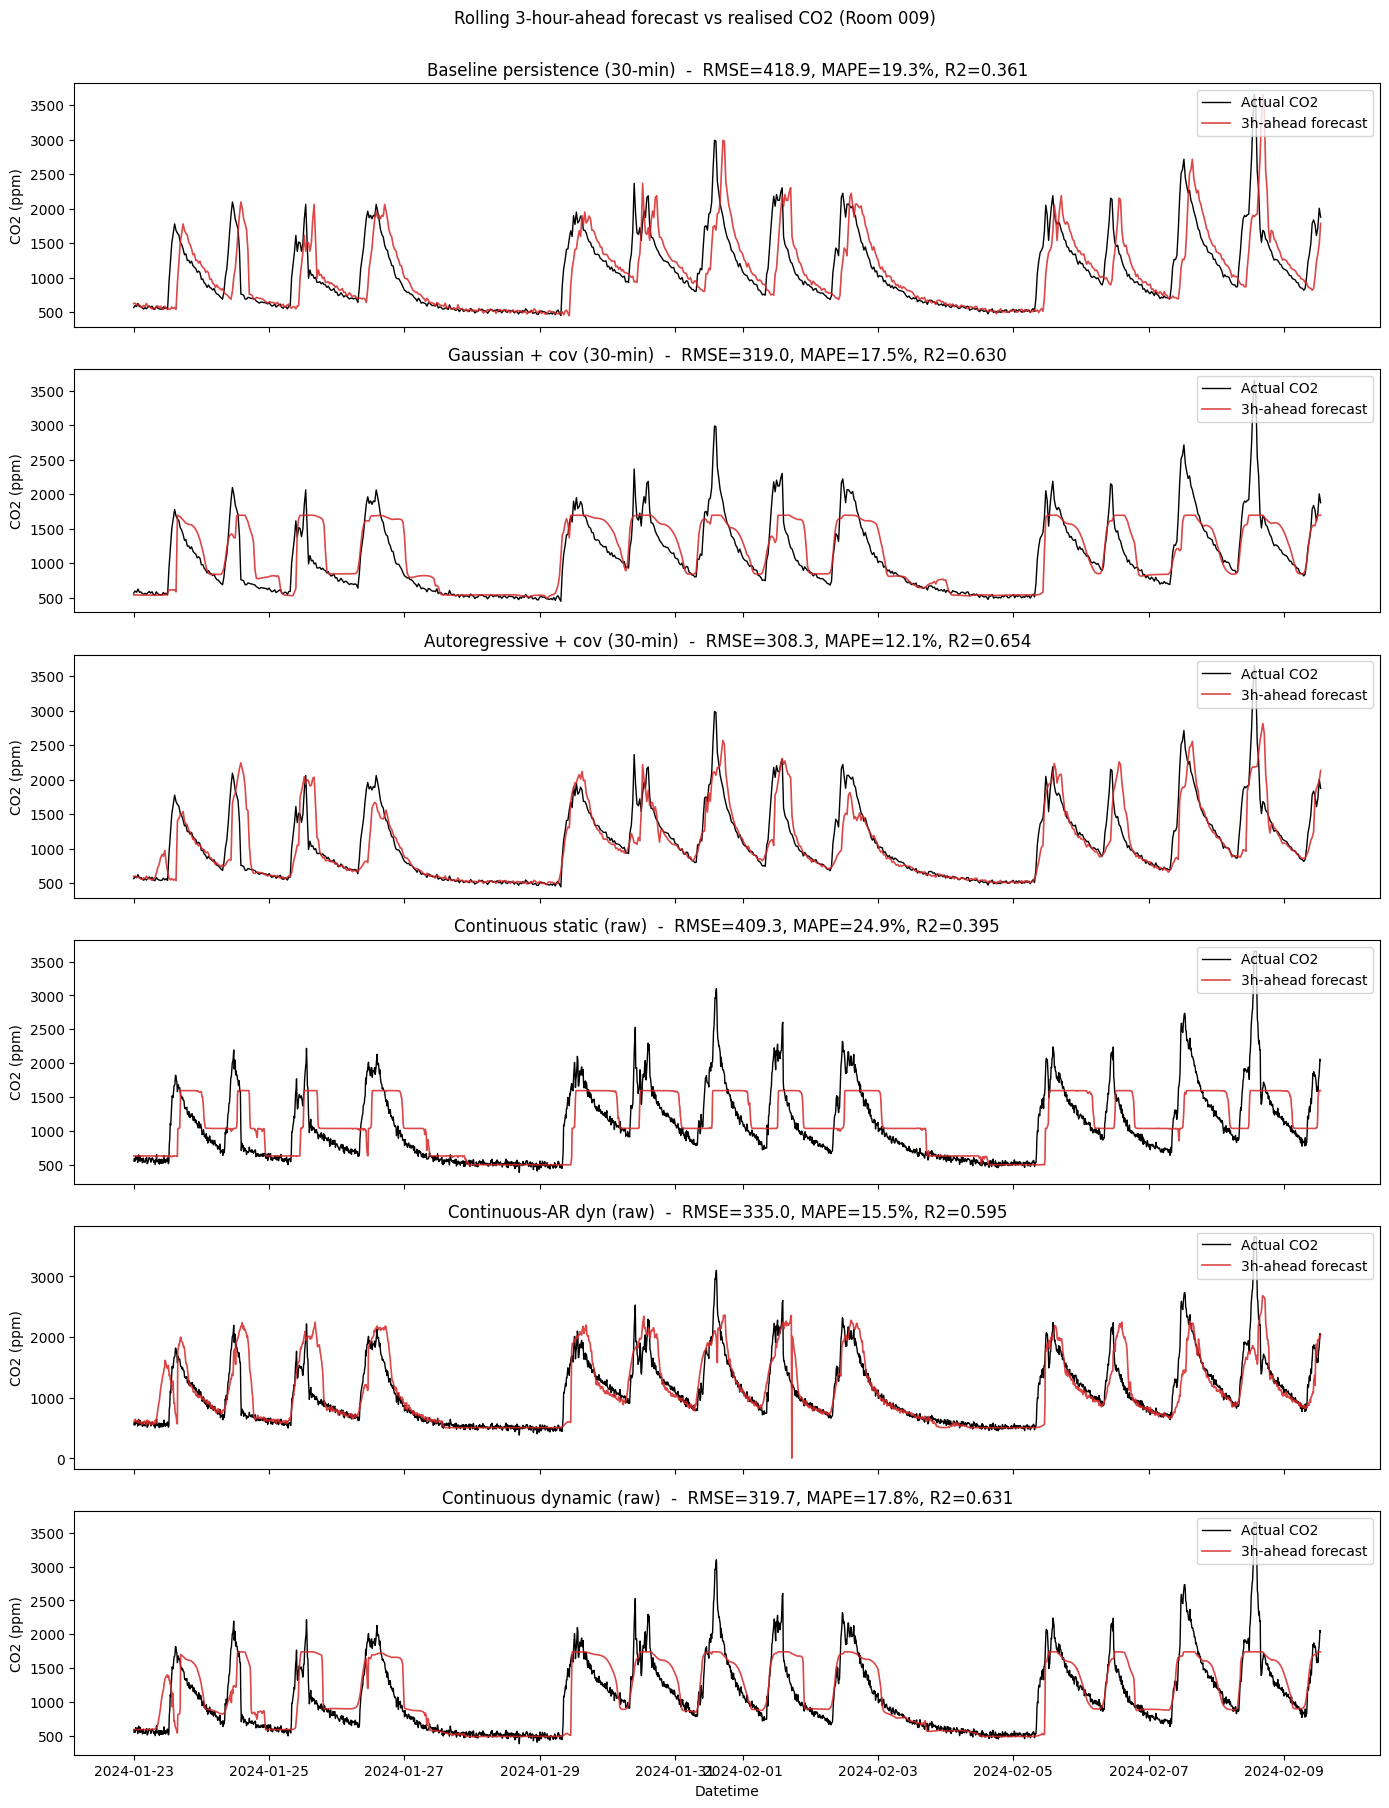

In [22]:
HORIZON_SEC = HORIZON_HOURS * 3600
K = int(round(HORIZON_SEC / BIN_SECONDS))       # 6 steps at 30 min


def rolling_baseline(ys, dates, train_idx, K):
    """Persistence: predict y[anchor+K] as the current value y[anchor] (30-min grid)."""
    ys = jnp.asarray(ys)
    anchors = jnp.arange(train_idx, len(ys) - K)
    y_pred = np.asarray(ys[anchors])          # current observation
    y_true = np.asarray(ys[anchors + K])      # realised 3 h later
    return dates[np.asarray(anchors) + K], y_true, y_pred


results = {}
results["Baseline persistence (30-min)"] = rolling_baseline(ys_agg, dates_agg, TRAIN_IDX_AGG, K)
results["Gaussian + cov (30-min)"]      = rolling_discrete(gauss_cov, ys_agg, X_agg_std, TRAIN_IDX_AGG, K, is_ar=False)
results["Autoregressive + cov (30-min)"] = rolling_discrete(ar_cov,   ys_agg, X_agg_std, TRAIN_IDX_AGG, K, is_ar=True)
results["Continuous static (raw)"]      = rolling_continuous(cont_static, ys_raw, ts_raw, dates_raw, None,      TRAIN_IDX_RAW, HORIZON_SEC)
#results["Continuous-AR dyn (30-min)"]   = rolling_ardecay(cont_ar_agg, ys_agg, ts_agg, dates_agg, X_agg_std, TRAIN_IDX_AGG, HORIZON_SEC)
results["Continuous-AR dyn (raw)"]      = rolling_ardecay(cont_ar_raw, ys_raw, ts_raw, dates_raw, X_raw_std, TRAIN_IDX_RAW, HORIZON_SEC)
results["Continuous dynamic (raw)"]     = rolling_continuous(cont_dyn,    ys_raw, ts_raw, dates_raw, X_raw_std, TRAIN_IDX_RAW, HORIZON_SEC)

print(f"{'Model':<32}{'RMSE':>9}{'MAPE%':>9}{'R2':>9}")
print("-" * 59)
for name, (td, yt, yp) in results.items():
    yt_j, yp_j = jnp.asarray(yt), jnp.asarray(yp)
    print(f"{name:<32}{rmse(yt_j, yp_j):9.2f}{mape(yt_j, yp_j):9.2f}{r2_score(yt_j, yp_j):9.4f}")

fig, axes = plt.subplots(len(results), 1, figsize=(14, 3 * len(results)), sharex=True)
for ax, (name, (td, yt, yp)) in zip(axes, results.items()):
    yt_j, yp_j = jnp.asarray(yt), jnp.asarray(yp)
    ax.plot(td, yt, color="black", lw=1.0, label="Actual CO2")
    ax.plot(td, yp, color="tab:red", lw=1.2, alpha=0.85, label=f"{HORIZON_HOURS}h-ahead forecast")
    ax.set_title(f"{name}  -  RMSE={rmse(yt_j, yp_j):.1f}, "
                 f"MAPE={mape(yt_j, yp_j):.1f}%, R2={r2_score(yt_j, yp_j):.3f}")
    ax.set_ylabel("CO2 (ppm)")
    ax.legend(loc="upper right")
axes[-1].set_xlabel("Datetime")
fig.suptitle(f"Rolling {HORIZON_HOURS}-hour-ahead forecast vs realised CO2 ({room_name})", y=1.002)
plt.tight_layout()
plt.show()

In [21]:
model = ar_cov

model.emission.mu_vals(t = 0, ys=0)

Array([ 444.14596169,  525.56103881,  530.81023376, 2442.52845332],      dtype=float64)